# Predicción de cancelaciones de reservas hoteleras

## Contexto
Las cancelaciones afectan la ocupación, los ingresos y la planificación de habitaciones. El dataset `hotel_bookings.csv` contiene información histórica de reservas y la variable `is_canceled`.

## Pregunta de negocio
**¿Podemos estimar, al momento de la reserva, la probabilidad de cancelación para priorizar acciones preventivas y mejorar la gestión de ocupación?**

## Objetivo
Comparar Regresión Logística y Random Forest mediante una validación temporal. El modelo elegido se guardará para usarlo en una demo web local.

## Prevención de fuga de información
Se excluyen `reservation_status`, `reservation_status_date` y `assigned_room_type` porque se conocen después de que la reserva evoluciona. También se excluyen `booking_changes` y `total_of_special_requests` para mantener una predicción estricta al momento de reservar.

No se eliminan automáticamente los duplicados exactos: el dataset no incluye un identificador de reserva y dos reservas distintas pueden tener las mismas características.

In [1]:
# 1. Librerías y configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
RUTA_ARCHIVO = 'hotel_bookings.csv'
RUTA_MODELO = 'hotel_cancellation_demo/hotel_cancellation_model.joblib'
MESES = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}

## 1. Obtención y comprensión de los datos

Dimensiones: 119,390 filas y 32 columnas
Cancelaciones: 37.0%
Duplicados exactos: 31,994


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


,nulos
children,4
country,488
agent,16340
company,112593


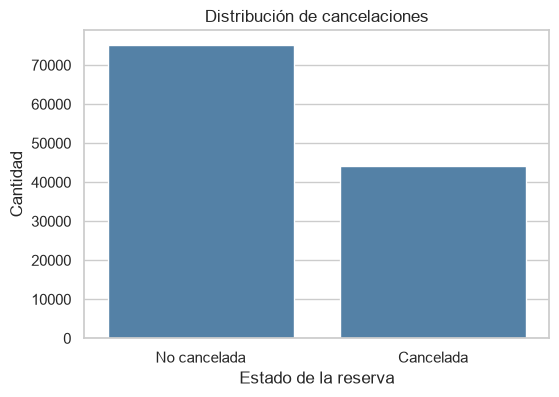

In [2]:
df = pd.read_csv(RUTA_ARCHIVO)
print(f'Dimensiones: {df.shape[0]:,} filas y {df.shape[1]} columnas')
print(f'Cancelaciones: {df.is_canceled.mean():.1%}')
print(f'Duplicados exactos: {df.duplicated().sum():,}')
display(df.head())
display(df.isna().sum()[df.isna().sum().gt(0)].to_frame('nulos'))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_canceled', color='steelblue')
plt.xticks([0, 1], ['No cancelada', 'Cancelada'])
plt.title('Distribución de cancelaciones')
plt.xlabel('Estado de la reserva')
plt.ylabel('Cantidad')
plt.show()

## 2. Preparación de variables
Las variables elegidas son conocidas al crear la reserva. Se convierte el mes de llegada en número y se separan variables numéricas y categóricas.

In [3]:
df_modelo = df.copy()
df_modelo['arrival_month_num'] = df_modelo['arrival_date_month'].map(MESES)

variables_numericas = [
    'lead_time', 'arrival_month_num', 'arrival_date_week_number', 'arrival_date_day_of_month',
    'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies',
    'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled',
    'days_in_waiting_list', 'adr'
]
variables_categoricas = [
    'hotel', 'meal', 'market_segment', 'distribution_channel',
    'reserved_room_type', 'deposit_type', 'customer_type'
]

X = df_modelo[variables_numericas + variables_categoricas]
y = df_modelo['is_canceled']

print(f'Variables numéricas: {len(variables_numericas)}')
print(f'Variables categóricas: {len(variables_categoricas)}')
display(df_modelo[variables_numericas].describe().round(2))

Variables numéricas: 14
Variables categóricas: 7


,lead_time,arrival_month_num,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,days_in_waiting_list,adr
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00
mean,104.01,6.55,27.17,15.80,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,2.32,101.83
std,106.86,3.09,13.61,8.78,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,17.59,50.54
min,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,-6.38
25%,18.00,4.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,69.29
50%,69.00,7.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,94.58
75%,160.00,9.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,126.00
max,737.00,12.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,391.00,5400.00


## 3. División temporal
Se entrena con reservas de 2015 y 2016, y se prueba con 2017. Esta división imita el uso real del modelo: aprender del pasado y evaluar en reservas futuras.

In [4]:
entrenamiento = df_modelo['arrival_date_year'] < 2017
X_train, X_test = X[entrenamiento], X[~entrenamiento]
y_train, y_test = y[entrenamiento], y[~entrenamiento]

print(f'Entrenamiento: {len(X_train):,} reservas')
print(f'Prueba temporal: {len(X_test):,} reservas')
print(f'Cancelaciones en prueba: {y_test.mean():.1%}')

Entrenamiento: 78,703 reservas
Prueba temporal: 40,687 reservas
Cancelaciones en prueba: 38.7%


## 4. Preprocesamiento y modelos
Las variables numéricas se imputan con mediana y se escalan para la regresión logística. Las categóricas se imputan con la categoría más frecuente y se codifican con One-Hot Encoding.

Se comparan una Regresión Logística como línea base y un Random Forest como modelo no lineal.

In [5]:
preprocesador = ColumnTransformer([
    ('numericas', Pipeline([
        ('imputar', SimpleImputer(strategy='median')),
        ('escalar', StandardScaler())
    ]), variables_numericas),
    ('categoricas', Pipeline([
        ('imputar', SimpleImputer(strategy='most_frequent')),
        ('codificar', OneHotEncoder(handle_unknown='ignore'))
    ]), variables_categoricas)
])

logistica = Pipeline([
    ('preprocesador', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])

bosque = Pipeline([
    ('preprocesador', preprocesador),
    ('modelo', RandomForestClassifier(
        n_estimators=200, max_depth=14, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1
    ))
])


In [6]:
def evaluar_modelo(nombre, modelo):
    modelo.fit(X_train, y_train)
    probabilidades = modelo.predict_proba(X_test)[:, 1]
    predicciones = (probabilidades >= 0.5).astype(int)
    return {
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, predicciones),
        'precision': precision_score(y_test, predicciones),
        'recall': recall_score(y_test, predicciones),
        'f1': f1_score(y_test, predicciones),
        'roc_auc': roc_auc_score(y_test, probabilidades),
        'modelo_entrenado': modelo,
        'probabilidades': probabilidades,
        'predicciones': predicciones
    }

resultado_logistica = evaluar_modelo('Regresión Logística', logistica)
resultado_bosque = evaluar_modelo('Random Forest', bosque)

resultados = pd.DataFrame([
    {k: v for k, v in resultado_logistica.items() if k not in ['modelo_entrenado', 'probabilidades', 'predicciones']},
    {k: v for k, v in resultado_bosque.items() if k not in ['modelo_entrenado', 'probabilidades', 'predicciones']}
])
display(resultados.round(3))

,modelo,accuracy,precision,recall,f1,roc_auc
0,Regresión Logística,0.691,0.579,0.741,0.650,0.782
1,Random Forest,0.715,0.605,0.757,0.673,0.806


## 5. Evaluación e interpretación
Se selecciona el modelo con mayor ROC-AUC. A diferencia de accuracy, esta métrica evalúa la capacidad de ordenar reservas desde menor a mayor riesgo de cancelación.

Modelo seleccionado: Random Forest
ROC-AUC: 0.806


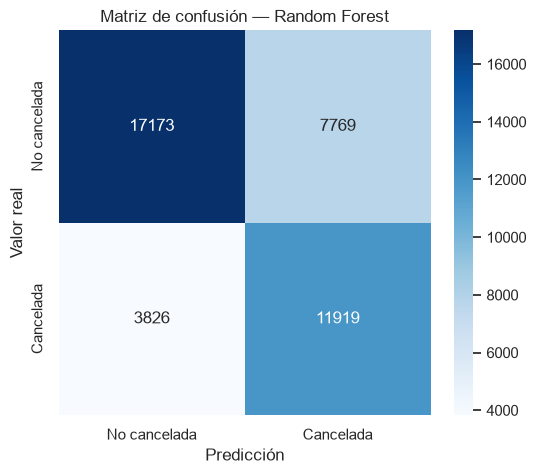

Umbral 0.30: se marcarían 63.9% de las reservas para gestión preventiva
Umbral 0.50: se marcarían 48.4% de las reservas para gestión preventiva
Umbral 0.70: se marcarían 10.2% de las reservas para gestión preventiva


In [7]:
mejor_resultado = max([resultado_logistica, resultado_bosque], key=lambda resultado: resultado['roc_auc'])
mejor_modelo = mejor_resultado['modelo_entrenado']
probabilidades = mejor_resultado['probabilidades']
predicciones = mejor_resultado['predicciones']

print(f"Modelo seleccionado: {mejor_resultado['modelo']}")
print(f"ROC-AUC: {mejor_resultado['roc_auc']:.3f}")

matriz = confusion_matrix(y_test, predicciones)
plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=['No cancelada', 'Cancelada'], yticklabels=['No cancelada', 'Cancelada'])
plt.title(f"Matriz de confusión — {mejor_resultado['modelo']}")
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

for umbral in [0.30, 0.50, 0.70]:
    tasa_alertas = (probabilidades >= umbral).mean()
    print(f'Umbral {umbral:.2f}: se marcarían {tasa_alertas:.1%} de las reservas para gestión preventiva')

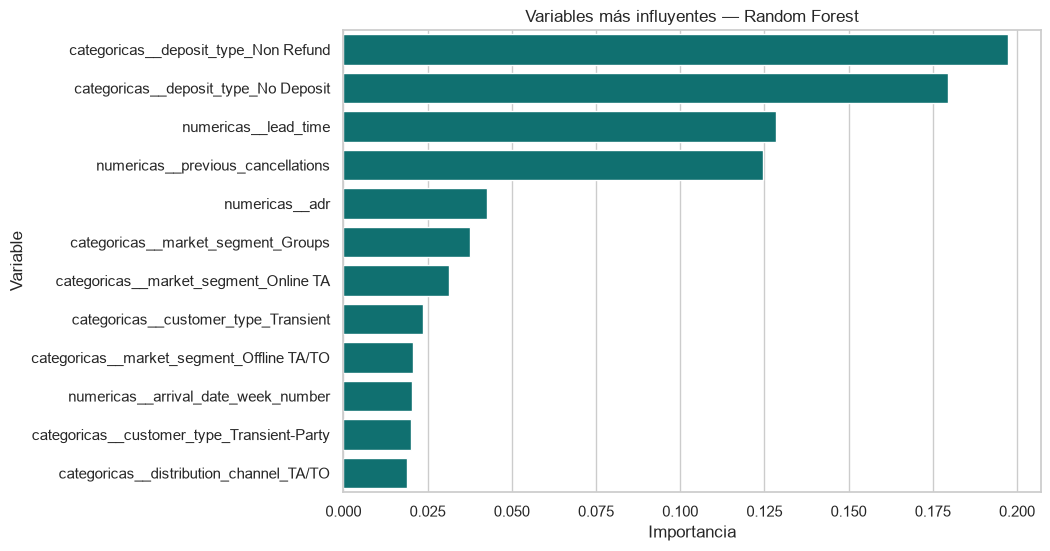

In [8]:
modelo_rf = resultado_bosque['modelo_entrenado']
nombres_variables = modelo_rf.named_steps['preprocesador'].get_feature_names_out()
importancias = pd.Series(
    modelo_rf.named_steps['modelo'].feature_importances_, index=nombres_variables
).sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 6))
sns.barplot(x=importancias.values, y=importancias.index, color='teal')
plt.title('Variables más influyentes — Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

## 6. Guardar modelo para la demo web
Se guarda el pipeline completo: incluye tratamiento de nulos, codificación y modelo. Así la página web utiliza exactamente las mismas transformaciones que el análisis.

In [9]:
joblib.dump(mejor_modelo, RUTA_MODELO)
print(f'Modelo guardado en: {RUTA_MODELO}')

Modelo guardado en: hotel_cancellation_demo/hotel_cancellation_model.joblib
